<a href="https://colab.research.google.com/github/Madhura-55/GenAI_course_learnings/blob/main/Word_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Word embeddings visualization (CBOW and SkipGram)

In [ ]:
# Install required libraries
!pip install nltk tensorflow scikit-learn matplotlib pandas numpy

# Import libraries
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten

# Download tokenizer resources
nltk.download('punkt')
nltk.download('punkt_tab')

print("Setup Complete")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Setup Complete


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Training corpus for Word2Vec learning

corpus = [
    "I love natural language processing",
    "Natural language processing is interesting",
    "Machine learning uses word embeddings",
    "Deep learning improves NLP systems",
    "Word2Vec learns semantic relationships",
    "Embeddings capture word meanings",
    "NLP uses machine learning techniques",
    "Artificial intelligence uses deep learning",
    "Machine learning and NLP are connected",
    "Word embeddings improve language understanding"
]

print("Corpus Sentences:\n")

for i, sentence in enumerate(corpus, start=1):
    print(f"{i}. {sentence}")

Corpus Sentences:

1. I love natural language processing
2. Natural language processing is interesting
3. Machine learning uses word embeddings
4. Deep learning improves NLP systems
5. Word2Vec learns semantic relationships
6. Embeddings capture word meanings
7. NLP uses machine learning techniques
8. Artificial intelligence uses deep learning
9. Machine learning and NLP are connected
10. Word embeddings improve language understanding


In [ ]:
# Store processed sentences
processed_corpus = []

for sentence in corpus:

    # Convert to lowercase
    sentence = sentence.lower()

    # Tokenize sentence
    tokens = word_tokenize(sentence)

    processed_corpus.append(tokens)

print("Processed Corpus:\n")

for sentence in processed_corpus:
    print(sentence)

Processed Corpus:

['i', 'love', 'natural', 'language', 'processing']
['natural', 'language', 'processing', 'is', 'interesting']
['machine', 'learning', 'uses', 'word', 'embeddings']
['deep', 'learning', 'improves', 'nlp', 'systems']
['word2vec', 'learns', 'semantic', 'relationships']
['embeddings', 'capture', 'word', 'meanings']
['nlp', 'uses', 'machine', 'learning', 'techniques']
['artificial', 'intelligence', 'uses', 'deep', 'learning']
['machine', 'learning', 'and', 'nlp', 'are', 'connected']
['word', 'embeddings', 'improve', 'language', 'understanding']


In [ ]:
# Collect all unique words
vocabulary = set()

for sentence in processed_corpus:
    vocabulary.update(sentence)

# Sort vocabulary for consistency
vocabulary = sorted(vocabulary)

# Create mappings
word_to_index = {}
index_to_word = {}

for index, word in enumerate(vocabulary):

    word_to_index[word] = index

    index_to_word[index] = word

print("Vocabulary Size:", len(vocabulary))

print("\nVocabulary:\n")
print(vocabulary)

print("\nWord → Index Mapping:\n")
print(word_to_index)

print("\nIndex → Word Mapping:\n")
print(index_to_word)

Vocabulary Size: 30

Vocabulary:

['and', 'are', 'artificial', 'capture', 'connected', 'deep', 'embeddings', 'i', 'improve', 'improves', 'intelligence', 'interesting', 'is', 'language', 'learning', 'learns', 'love', 'machine', 'meanings', 'natural', 'nlp', 'processing', 'relationships', 'semantic', 'systems', 'techniques', 'understanding', 'uses', 'word', 'word2vec']

Word → Index Mapping:

{'and': 0, 'are': 1, 'artificial': 2, 'capture': 3, 'connected': 4, 'deep': 5, 'embeddings': 6, 'i': 7, 'improve': 8, 'improves': 9, 'intelligence': 10, 'interesting': 11, 'is': 12, 'language': 13, 'learning': 14, 'learns': 15, 'love': 16, 'machine': 17, 'meanings': 18, 'natural': 19, 'nlp': 20, 'processing': 21, 'relationships': 22, 'semantic': 23, 'systems': 24, 'techniques': 25, 'understanding': 26, 'uses': 27, 'word': 28, 'word2vec': 29}

Index → Word Mapping:

{0: 'and', 1: 'are', 2: 'artificial', 3: 'capture', 4: 'connected', 5: 'deep', 6: 'embeddings', 7: 'i', 8: 'improve', 9: 'improves', 10:

In [ ]:
# Context window size
window_size = 1

# Store CBOW training data
X_cbow = []
y_cbow = []

for sentence in processed_corpus:

    for i in range(window_size, len(sentence) - window_size):

        # Context words
        context = [
            sentence[i-1],
            sentence[i+1]
        ]

        # Target word
        target = sentence[i]

        # Convert words to indices
        context_indices = [
            word_to_index[word]
            for word in context
        ]

        target_index = word_to_index[target]

        X_cbow.append(context_indices)
        y_cbow.append(target_index)

print("CBOW Context Inputs:\n")
print(X_cbow[:10])

print("\nCBOW Targets:\n")
print(y_cbow[:10])

print("\nExample Training Pairs:\n")

for i in range(5):

    context_words = [
        index_to_word[idx]
        for idx in X_cbow[i]
    ]

    target_word = index_to_word[y_cbow[i]]

    print(
        context_words,
        "→",
        target_word
    )

CBOW Context Inputs:

[[7, 19], [16, 13], [19, 21], [19, 21], [13, 12], [21, 11], [17, 27], [14, 28], [27, 6], [5, 9]]

CBOW Targets:

[16, 19, 13, 13, 21, 12, 14, 27, 28, 14]

Example Training Pairs:

['i', 'natural'] → love
['love', 'language'] → natural
['natural', 'processing'] → language
['natural', 'processing'] → language
['language', 'is'] → processing


In [ ]:
# Convert training data to NumPy arrays
X_cbow = np.array(X_cbow)
y_cbow = np.array(y_cbow)

# Vocabulary size
vocab_size = len(vocabulary)

# Embedding vector dimension
embedding_dim = 10

# Build CBOW model
cbow_model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=2
    ),

    Flatten(),

    Dense(vocab_size, activation='softmax')

])

# Compile model
cbow_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
cbow_model.summary()

# Train model
history = cbow_model.fit(
    X_cbow,
    y_cbow,
    epochs=100,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step - accuracy: 0.0000e+00 - loss: 3.4048
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0345 - loss: 3.4008
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0345 - loss: 3.3967
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0690 - loss: 3.3927
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.1034 - loss: 3.3887
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1379 - loss: 3.3847
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1379 - loss: 3.3807
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1724 - loss: 3.3766
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2069 - loss: 3.3726
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2069 - loss: 3.3686
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2069 - loss: 3.3646
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2414

In [ ]:
# Extract embedding weights from trained CBOW model
embedding_weights = cbow_model.layers[0].get_weights()[0]

print("Embedding Matrix Shape:\n")
print(embedding_weights.shape)

print("\nSample Word Embeddings:\n")

for word in vocabulary[:10]:

    index = word_to_index[word]

    print(
        f"{word} → {embedding_weights[index]}"
    )

Embedding Matrix Shape:

(30, 10)

Sample Word Embeddings:

and → [ 0.12410913 -0.16656949  0.11897109 -0.13171074  0.14759438  0.11542591
  0.04713196  0.18134736  0.06794095 -0.16461445]
are → [ 0.1202037  -0.0901382   0.077941   -0.08833212  0.12222962  0.1459436
  0.07875862 -0.13257343 -0.07575696 -0.13018824]
artificial → [ 0.0220695   0.14604716 -0.06484014  0.14017512 -0.08872733  0.12283773
  0.10689791 -0.14571384 -0.06729273  0.08836545]
capture → [ 0.1518536  -0.14368626  0.14483811 -0.04749811  0.0629626  -0.15236518
  0.02836507  0.1530508  -0.08633903 -0.05049903]
connected → [ 0.0892696  -0.1454161  -0.1742529  -0.1369598   0.13684446 -0.12969422
 -0.15705311  0.05103603 -0.08799119  0.09351532]
deep → [ 0.18566205  0.19424696 -0.19004785 -0.06874183  0.11591867 -0.11996755
  0.13125399  0.14448029 -0.09975614 -0.0104819 ]
embeddings → [-0.20304036  0.20319393  0.11836557 -0.12338396  0.08743943 -0.06792359
 -0.22426784 -0.03684167  0.1538695   0.0589569 ]
i → [ 0.12719

In [ ]:
# Store Skip-Gram training data
X_skipgram = []
y_skipgram = []

window_size = 1

for sentence in processed_corpus:

    for i in range(len(sentence)):

        center_word = sentence[i]

        # Left context
        start = max(0, i - window_size)

        # Right context
        end = min(
            len(sentence),
            i + window_size + 1
        )

        # Generate surrounding words
        for j in range(start, end):

            if i != j:

                context_word = sentence[j]

                X_skipgram.append(
                    word_to_index[
                        center_word
                    ]
                )

                y_skipgram.append(
                    word_to_index[
                        context_word
                    ]
                )

print("Skip-Gram Inputs:\n")
print(X_skipgram[:10])

print("\nSkip-Gram Targets:\n")
print(y_skipgram[:10])

print("\nExample Training Pairs:\n")

for i in range(10):

    center = index_to_word[
        X_skipgram[i]
    ]

    target = index_to_word[
        y_skipgram[i]
    ]

    print(
        center,
        "→",
        target
    )

Skip-Gram Inputs:

[7, 16, 16, 19, 19, 13, 13, 21, 19, 13]

Skip-Gram Targets:

[16, 7, 19, 16, 13, 19, 21, 13, 13, 19]

Example Training Pairs:

i → love
love → i
love → natural
natural → love
natural → language
language → natural
language → processing
processing → language
natural → language
language → natural


In [ ]:
# Convert Skip-Gram data to NumPy arrays
X_skipgram = np.array(X_skipgram)
y_skipgram = np.array(y_skipgram)

# Build Skip-Gram model
skipgram_model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=1
    ),

    Flatten(),

    Dense(
        vocab_size,
        activation='softmax'
    )

])

# Compile model
skipgram_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
skipgram_model.summary()

# Train model
history_skipgram = skipgram_model.fit(
    X_skipgram,
    y_skipgram,
    epochs=100,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0128 - loss: 3.4040      
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0256 - loss: 3.3998     
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0513 - loss: 3.3960
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0513 - loss: 3.3924 
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0641 - loss: 3.3889 
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0769 - loss: 3.3853 
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1026 - loss: 3.3816 
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1410 - loss: 3.3782 
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2051 - loss: 3.3745 
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2179 - loss: 3.3709 
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2308 - loss: 3.3674 
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2

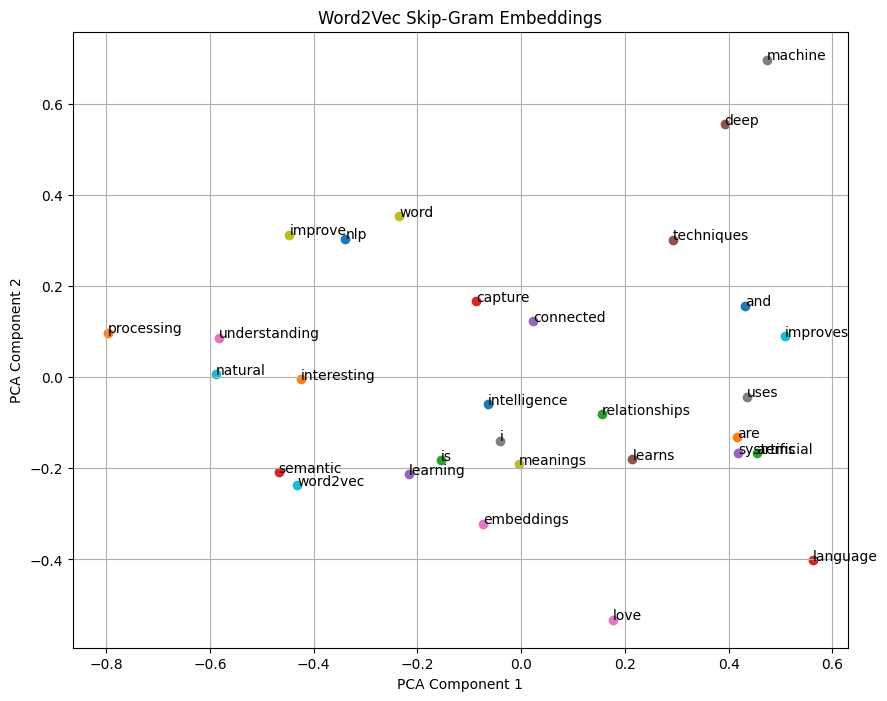

In [ ]:
# Extract Skip-Gram embeddings
skipgram_embeddings = (
    skipgram_model.layers[0]
    .get_weights()[0]
)

# Reduce dimensions using PCA
pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(
    skipgram_embeddings
)

# Plot embeddings
plt.figure(figsize=(10,8))

for i, word in enumerate(vocabulary):

    x = reduced_embeddings[i][0]
    y = reduced_embeddings[i][1]

    plt.scatter(x, y)

    plt.annotate(
        word,
        (x, y)
    )

plt.title(
    "Word2Vec Skip-Gram Embeddings"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.grid()

plt.show()